## Modelos para la tercera entrega

Se seleccionaron las siguientes variables para climáticas para construir el modelo

| Variable | Significado                        | Justificación                   |
| -------- | ---------------------------------- | ------------------------------- |
| `bio01`  | Temperatura media anual            | General, robusta                |
| `bio03`  | Isotermalidad                      | Captura variabilidad térmica    |
| `bio04`  | Rango de temperatura anual         | Complementa `bio01`             |
| `bio07`  | Amplitud térmica anual             | Importante en zonas montañosas  |
| `bio12`  | Precipitación anual                | Indicador hídrico clave         |
| `bio15`  | Estacionalidad de la precipitación | Representa variabilidad hídrica |

In [5]:
import geopandas as gpd
import pandas as pd

wc = pd.read_csv('../data/WorldClim_v2.csv')


# Convertir a GeoDataFrame para reproyectar
geo = gpd.GeoDataFrame(
    wc,
    geometry=gpd.points_from_xy(wc['lon'], wc['lat']),
    crs='EPSG:4326'
)
#geo = geo.to_crs(epsg=3857)


## Matriz de pesos basada en distancias

In [6]:
# Importamos el shapefile de cuencas tanto el de POMCAS como el de hydrosheds
cuencas = gpd.read_file('C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/shapes/POMCAS.gpkg')
hydro = gpd.read_file('C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/shapes/HydroBasins/hybas_sa_lev10_v1c.shp')

c:\Users\danie\miniconda3\envs\GeoSpatial\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: Non-conformant content for record 1 in column Fecha_Ingr, 2021-05-06T00:00:00.0Z, successfully parsed
  return ogr_read(


In [4]:
cuencas.crs
# hydro.crs

<Projected CRS: PROJCS["MAGNA-SIRGAS / Origen-Nacional",GEOGCS["MA ...>
Name: MAGNA-SIRGAS / Origen-Nacional
Axis Info [cartesian]:
- [east]: Easting (metre)
- [north]: Northing (metre)
Area of Use:
- undefined
Coordinate Operation:
- name: unnamed
- method: Transverse Mercator
Datum: Marco Geocentrico Nacional de Referencia
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [27]:
hydro.info()
hydro.head()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 123438 entries, 0 to 123437
Data columns (total 14 columns):
 #   Column     Non-Null Count   Dtype   
---  ------     --------------   -----   
 0   HYBAS_ID   123438 non-null  int64   
 1   NEXT_DOWN  123438 non-null  int64   
 2   NEXT_SINK  123438 non-null  int64   
 3   MAIN_BAS   123438 non-null  int64   
 4   DIST_SINK  123438 non-null  float64 
 5   DIST_MAIN  123438 non-null  float64 
 6   SUB_AREA   123438 non-null  float64 
 7   UP_AREA    123438 non-null  float64 
 8   PFAF_ID    123438 non-null  int64   
 9   ENDO       123438 non-null  int32   
 10  COAST      123438 non-null  int32   
 11  ORDER      123438 non-null  int32   
 12  SORT       123438 non-null  int64   
 13  geometry   123438 non-null  geometry
dtypes: float64(4), geometry(1), int32(3), int64(6)
memory usage: 11.8 MB


,HYBAS_ID,NEXT_DOWN,NEXT_SINK,MAIN_BAS,DIST_SINK,DIST_MAIN,SUB_AREA,UP_AREA,PFAF_ID,ENDO,COAST,ORDER,SORT,geometry
0,6100000010,0,6100000010,6100000010,0.0,0.0,222.1,222.5,6110010100,0,1,0,1,"MULTIPOLYGON (((-79.26667 9.425, -79.2672 9.42..."
1,6100000020,0,6100000020,6100000020,0.0,0.0,71.2,335.7,6110010201,0,0,1,2,"POLYGON ((-79.1 9.40417, -79.10035 9.40659, -7..."
2,6100064350,6100000020,6100000020,6100000020,8.6,8.6,104.4,104.4,6110010203,0,0,1,3,"POLYGON ((-79.27083 9.31667, -79.27415 9.31752..."
3,6100064340,6100000020,6100000020,6100000020,8.7,8.7,160.1,160.1,6110010202,0,0,2,4,"POLYGON ((-79.25417 9.35, -79.25355 9.35216, -..."
4,6100000030,0,6100000030,6100000030,0.0,0.0,114.9,115.0,6110010310,0,1,0,5,"MULTIPOLYGON (((-79.09583 9.33333, -79.10833 9..."


In [7]:
# Reproyectar las ocurrencias al crs de las cuencas y tambien las cuencas de hidrosheds
geo = geo.to_crs(cuencas.crs)
geo.crs

<Projected CRS: PROJCS["MAGNA-SIRGAS / Origen-Nacional",GEOGCS["MA ...>
Name: MAGNA-SIRGAS / Origen-Nacional
Axis Info [cartesian]:
- [east]: Easting (metre)
- [north]: Northing (metre)
Area of Use:
- undefined
Coordinate Operation:
- name: unnamed
- method: Transverse Mercator
Datum: Marco Geocentrico Nacional de Referencia
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [8]:
hydro = hydro.to_crs(cuencas.crs)
hydro.crs

<Projected CRS: PROJCS["MAGNA-SIRGAS / Origen-Nacional",GEOGCS["MA ...>
Name: MAGNA-SIRGAS / Origen-Nacional
Axis Info [cartesian]:
- [east]: Easting (metre)
- [north]: Northing (metre)
Area of Use:
- undefined
Coordinate Operation:
- name: unnamed
- method: Transverse Mercator
Datum: Marco Geocentrico Nacional de Referencia
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [9]:
# Seleccionar solo los polígonos que contienen al menos un punto
# la forma más eficiente con unary_union
# cuencas_ocur = cuencas[cuencas.geometry.intersects(geo.unary_union)]
cuencas_ocur = hydro[hydro.geometry.intersects(geo.unary_union)] # Hacemos el cambio al shape de hydrosheds

C:\Users\danie\AppData\Local\Temp\ipykernel_23208\2572093903.py:4: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  cuencas_ocur = hydro[hydro.geometry.intersects(geo.unary_union)] # Hacemos el cambio al shape de hydrosheds


(293, 14)

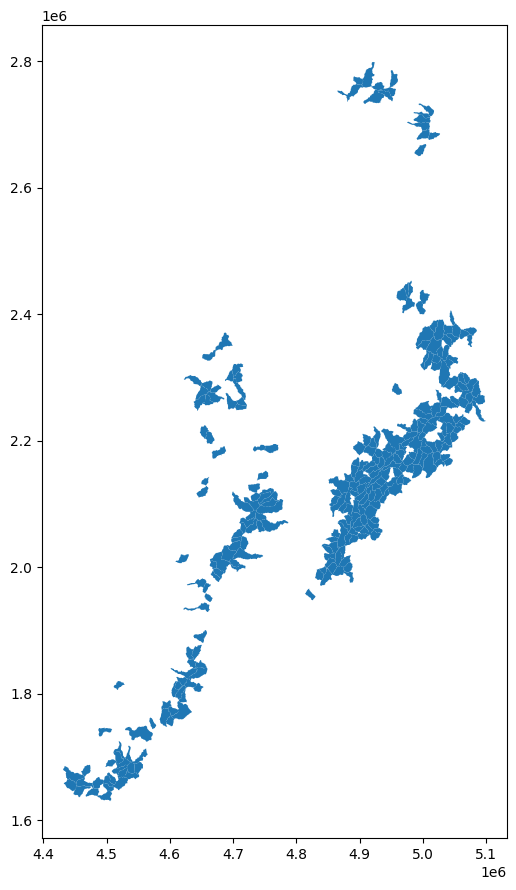

In [10]:
# hacer la figura mas grandes
cuencas_ocur.plot(figsize=(6, 12))
cuencas_ocur.shape

In [11]:
pomca = cuencas_ocur.copy() # solo donde hay ocurrencias

In [12]:
geo.columns
#grid.columns

Index(['Unnamed: 0', 'countryCode', 'elevation_DEM', 'genus', 'lat', 'lon',
       'species', 'bio1', 'bio3', 'bio4', 'bio7', 'bio12', 'bio15', '.geo',
       'geometry'],
      dtype='object')

### Usar raster satatistic para extraer el valor del raster para todo el poligono

In [13]:
import glob
import os

images = []
for n in ['1','3','4','7','12','15']:
    file = f'C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/WorldClim_Bio_Images/wc2.1_30s_bio_{n}.tif'
    images.append(file)
# for file in glob.glob("C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/WorldClim_Bio_Images/*.tif"):
#     # images.append(os.path.basename(file)) # Solo el archivo
#     images.append(file) 

In [41]:
images

['C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/WorldClim_Bio_Images/wc2.1_30s_bio_1.tif',
 'C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/WorldClim_Bio_Images/wc2.1_30s_bio_3.tif',
 'C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/WorldClim_Bio_Images/wc2.1_30s_bio_4.tif',
 'C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/WorldClim_Bio_Images/wc2.1_30s_bio_7.tif',
 'C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/WorldClim_Bio_Images/wc2.1_30s_bio_12.tif',
 'C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/WorldClim_Bio_Images/wc2.1_30s_bio_15.tif']

In [14]:
geo = geo.to_crs(epsg=4326) 
pomca = pomca.to_crs(epsg=4326) # Poner todo en el mismo sistema de coordeadas
print(pomca.crs)
geo.crs

EPSG:4326


<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [15]:
pomca.columns

Index(['HYBAS_ID', 'NEXT_DOWN', 'NEXT_SINK', 'MAIN_BAS', 'DIST_SINK',
       'DIST_MAIN', 'SUB_AREA', 'UP_AREA', 'PFAF_ID', 'ENDO', 'COAST', 'ORDER',
       'SORT', 'geometry'],
      dtype='object')

In [16]:
from rasterstats import zonal_stats

# --- Spatial join para species (esto sí se hace con los puntos) ---
join = gpd.sjoin(
    geo,
    pomca[['HYBAS_ID', 'NEXT_DOWN', 'NEXT_SINK', 'MAIN_BAS', 'DIST_SINK','DIST_MAIN', 'SUB_AREA', 'geometry']],
    how='inner',
    predicate='within'
)

# --- Conteo de species por POMCA ---
# Número de especies únicas por POMCA
conteo = join.groupby('HYBAS_ID')['species'].nunique()

# Número total de puntos por POMCA
conteo_puntos = join.groupby('HYBAS_ID').size()

# Asignar conteos a POMCA
pomca['num_species'] = pomca['HYBAS_ID'].map(conteo).fillna(0).astype(int)
pomca['num_points'] = pomca['HYBAS_ID'].map(conteo_puntos).fillna(0).astype(int)

# --- Zonal stats para biovariables ---
# IMPORTANTE: Asocia cada variable a su raster
bio_vars = {
    'bio1': 'C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/WorldClim_Bio_Images/wc2.1_30s_bio_1.tif',
    'bio3': 'C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/WorldClim_Bio_Images/wc2.1_30s_bio_3.tif',
    'bio4': 'C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/WorldClim_Bio_Images/wc2.1_30s_bio_4.tif',
    'bio7': 'C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/WorldClim_Bio_Images/wc2.1_30s_bio_7.tif',
    'bio12': 'C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/WorldClim_Bio_Images/wc2.1_30s_bio_12.tif',
    'bio15': 'C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/WorldClim_Bio_Images/wc2.1_30s_bio_15.tif'
}

# Loop por cada raster → 1 sola vez
for var, tif_path in bio_vars.items():
    zs = zonal_stats(pomca, tif_path, stats=['mean'])
    pomca[f'{var}_mean'] = [x['mean'] for x in zs]

# --- Elevation ---
zs_elev = zonal_stats(
    pomca,
    'C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/WorldClim_Bio_Images/wc2.1_30s_elev.tif',
    stats=['mean']
)
pomca['elevacion'] = [x['mean'] for x in zs_elev]

# --- Verificación ---
print(pomca[['HYBAS_ID', 'num_species', 'num_points',
             'bio1_mean', 'bio3_mean', 'bio4_mean',
             'bio7_mean', 'bio12_mean', 'bio15_mean',
             'elevacion']].head())



       HYBAS_ID  num_species  num_points  bio1_mean  bio3_mean  bio4_mean  \
145  6100091600            1           1  17.572584  85.340537  36.650179   
169  6100994880            2         610  14.664964  88.400100  32.547114   
201  6100096290            1           1  18.183105  86.292007  32.794186   
217  6100099730            2          16  16.977023  89.152358  30.985352   
218  6100099640            2          31  14.819224  88.266386  29.936962   

     bio7_mean   bio12_mean  bio15_mean    elevacion  
145  10.468831  2366.480519   49.477979  1993.303030  
169   9.637981  2403.649038   43.160297  2497.600962  
201  10.201172  2519.269531   44.124008  1836.945312  
217  10.146429  2388.546429   39.001360  2103.692857  
218   9.657874  2357.157480   41.711814  2439.641732  


In [17]:
pomca.columns

Index(['HYBAS_ID', 'NEXT_DOWN', 'NEXT_SINK', 'MAIN_BAS', 'DIST_SINK',
       'DIST_MAIN', 'SUB_AREA', 'UP_AREA', 'PFAF_ID', 'ENDO', 'COAST', 'ORDER',
       'SORT', 'geometry', 'num_species', 'num_points', 'bio1_mean',
       'bio3_mean', 'bio4_mean', 'bio7_mean', 'bio12_mean', 'bio15_mean',
       'elevacion'],
      dtype='object')

In [18]:
# Filtrar: solo celdas con al menos 1 punto (puedes usar num_points o num_species)
# pomca_filt = pomca[pomca['num_points'] > 0].copy()
pomca_filt = pomca[['HYBAS_ID','MAIN_BAS','num_species', 'num_points',
             'bio1_mean', 'bio3_mean', 'bio4_mean', 'bio7_mean', 'bio12_mean', 'bio15_mean','elevacion', 'geometry']].copy() # todas las cuencas
pomca_filt.shape


(293, 12)

In [ ]:
# Filtrar polígonos con área > 0
#pomca_filt = pomca_filt[pomca_filt['Area_Ha'] > 0].copy()
# pomca_filt = join_pomca[join_pomca['num_species'] > 0].copy()
# pomca_filt.shape

(1390, 20)

In [19]:
pomca_filt.columns

Index(['HYBAS_ID', 'MAIN_BAS', 'num_species', 'num_points', 'bio1_mean',
       'bio3_mean', 'bio4_mean', 'bio7_mean', 'bio12_mean', 'bio15_mean',
       'elevacion', 'geometry'],
      dtype='object')

### Indice de Moran

In [20]:
import numpy as np

# Crear columna de densidad de especies por km2
# pomca_filt['sp_density'] = pomca_filt['num_species'] / (pomca_filt['Area_Ha'] / 100)  # convertir de Ha a Km2
# #pomca_filt['log_sp_density'] = np.log1p(pomca_filt['sp_density'])
# pomca_filt['sp_density'].isna().sum()  # Ver si hay NaN

In [21]:
pomca_filt['sp_density'] = pomca_filt['num_species'] / pomca_filt.geometry.area

C:\Users\danie\AppData\Local\Temp\ipykernel_23208\720122719.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  pomca_filt['sp_density'] = pomca_filt['num_species'] / pomca_filt.geometry.area


In [22]:
from libpysal.weights import DistanceBand


# Crear matriz DistanceBand (por ejemplo 20 km)
w_dist20km = DistanceBand.from_dataframe(pomca_filt, threshold=20000, binary=False)
w_dist50km = DistanceBand.from_dataframe(pomca_filt, threshold=50000, binary=False)
w_dist100km = DistanceBand.from_dataframe(pomca_filt, threshold=100000, binary=False)

c:\Users\danie\miniconda3\envs\GeoSpatial\Lib\site-packages\scipy\sparse\_data.py:128: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)


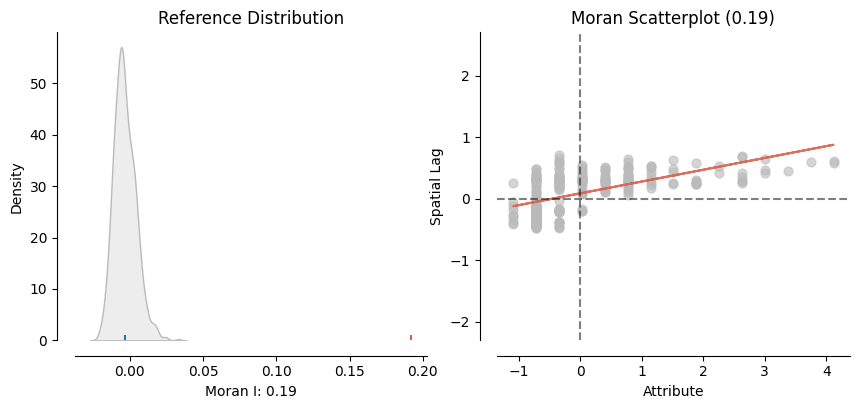

In [24]:
import esda
from splot.esda import plot_moran

# Moran para distancia de 30 km
mi = esda.Moran(pomca_filt['num_species'], w_dist20km)
plot_moran(mi);

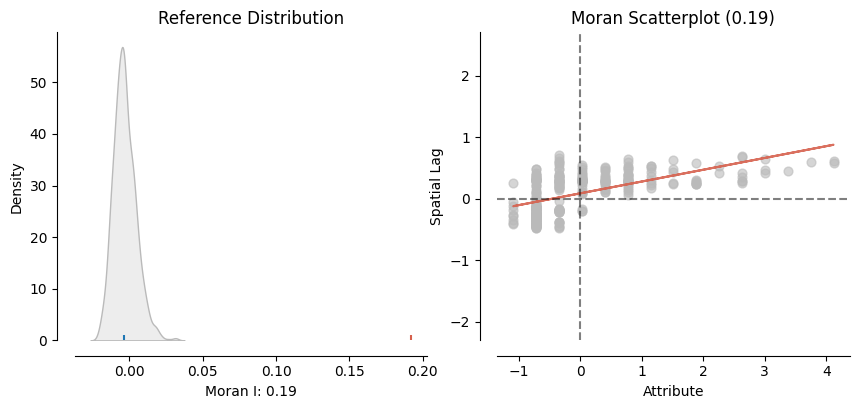

In [25]:
# Moran con 50 km
plot_moran(esda.Moran(pomca_filt['num_species'], w_dist50km));

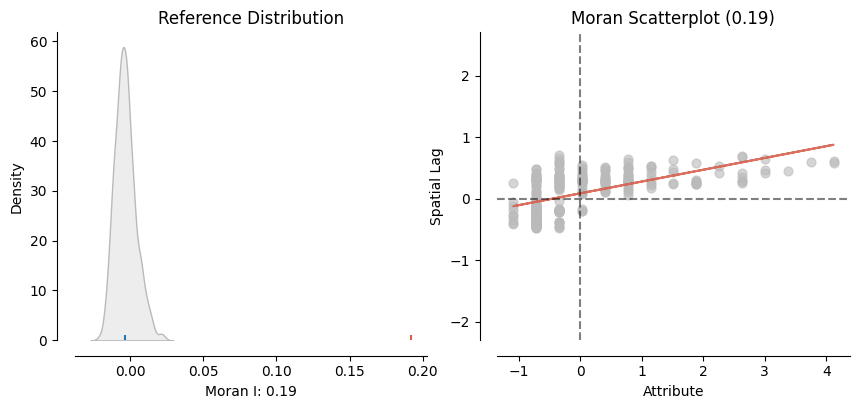

In [26]:
# Moran con 100 km
plot_moran(esda.Moran(pomca_filt['num_species'], w_dist100km));

In [27]:
from pysal.lib import weights

# Primero para numero de especies
pomca_filt['num_species_std'] = (pomca_filt['num_species'] - pomca_filt['num_species'].mean()) / pomca_filt['num_species'].std()
pomca_filt['w_num_species_std'] = weights.lag_spatial(w_dist50km, pomca_filt['num_species_std'])

# Ahora para numero de ocurrencias
pomca_filt['num_points_std'] = (pomca_filt['num_points'] - pomca_filt['num_points'].mean()) / pomca_filt['num_points'].std()
pomca_filt['w_num_points_std'] = weights.lag_spatial(w_dist50km, pomca_filt['num_points_std'])

# Ahora para densidad de especies
pomca_filt['sp_density_std'] = (pomca_filt['sp_density'] - pomca_filt['sp_density'].mean()) / pomca_filt['sp_density'].std()
pomca_filt['w_sp_density_std'] = weights.lag_spatial(w_dist50km, pomca_filt['sp_density_std'])

In [28]:
pomca_filt.columns

Index(['HYBAS_ID', 'MAIN_BAS', 'num_species', 'num_points', 'bio1_mean',
       'bio3_mean', 'bio4_mean', 'bio7_mean', 'bio12_mean', 'bio15_mean',
       'elevacion', 'geometry', 'sp_density', 'num_species_std',
       'w_num_species_std', 'num_points_std', 'w_num_points_std',
       'sp_density_std', 'w_sp_density_std'],
      dtype='object')

In [ ]:
# pomca_filt.to_file('../data/regresion_POMCA_Final.geojson', driver="GeoJSON")

### A partir de acá podemos traer el dataframe listo

In [ ]:
import geopandas as gpd
import pandas as pd
from pysal.lib import weights
import esda
from splot.esda import plot_moran
import numpy as np
from libpysal.weights import DistanceBand

# Traer el dataframe sin repetir todo el proceso
pomca_filt = gpd.read_file('../data/regresion_POMCA_Final.geojson')

In [6]:
pomca_filt['log_num_species'] = np.log1p(pomca_filt['num_species'])
pomca_filt['log_sp_density'] = np.log1p(pomca_filt['sp_density'])

In [10]:
pomca_filt.columns

Index(['HYBAS_ID', 'MAIN_BAS', 'num_species', 'num_points', 'bio1_mean',
       'bio3_mean', 'bio4_mean', 'bio7_mean', 'bio12_mean', 'bio15_mean',
       'elevacion', 'sp_density', 'num_species_std', 'w_num_species_std',
       'num_points_std', 'w_num_points_std', 'sp_density_std',
       'w_sp_density_std', 'geometry', 'log_num_species', 'log_sp_density'],
      dtype='object')

In [7]:
from libpysal.weights import DistanceBand

# Crear matriz DistanceBand (por ejemplo 20 km)
w_dist20km = DistanceBand.from_dataframe(pomca_filt, threshold=20000, binary=False)
w_dist50km = DistanceBand.from_dataframe(pomca_filt, threshold=50000, binary=False)
w_dist100km = DistanceBand.from_dataframe(pomca_filt, threshold=100000, binary=False)

c:\Users\danie\miniconda3\envs\GeoSpatial\Lib\site-packages\scipy\sparse\_data.py:128: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)


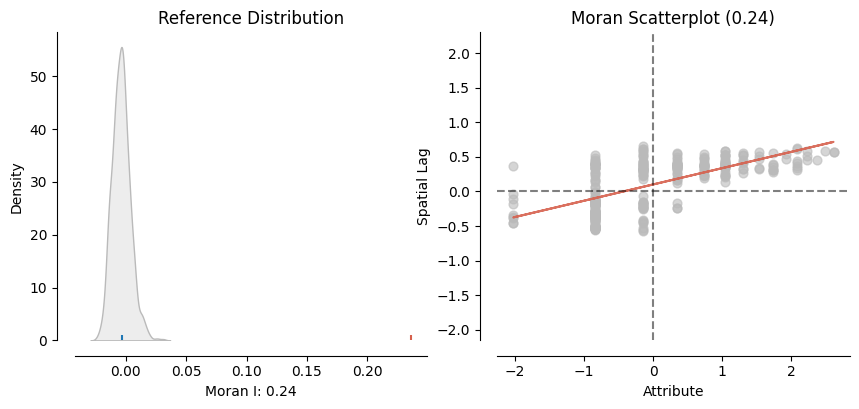

In [9]:
# Moran con 100 km
plot_moran(esda.Moran(pomca_filt['log_num_species'], w_dist100km));

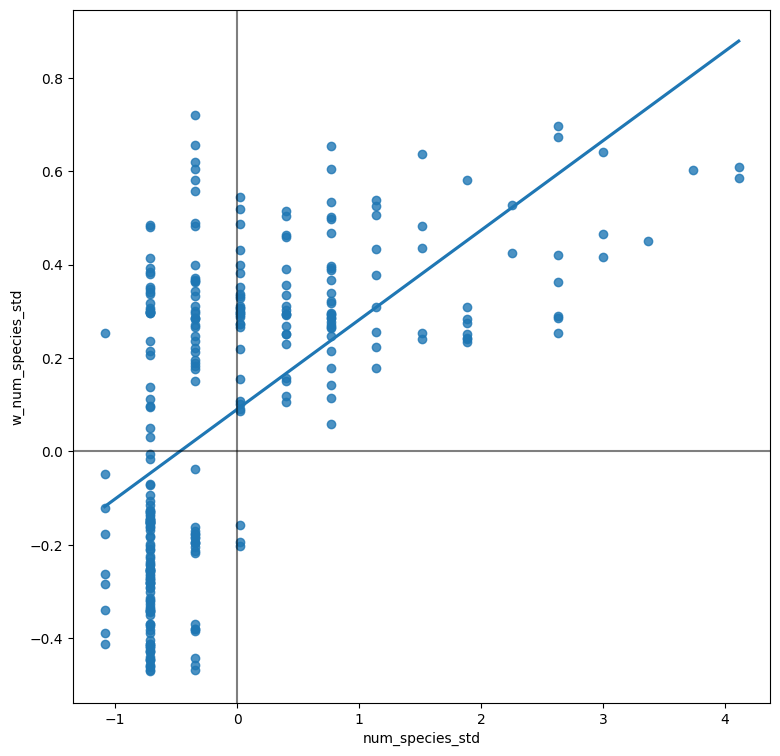

In [11]:
# Grafico LISA
import seaborn as sbn
import matplotlib.pyplot as plt

# Setup the figure and axis
f, ax = plt.subplots(1, figsize=(9, 9))
# Plot values
sbn.regplot(x='num_species_std', y='w_num_species_std', data=pomca_filt, ci=None)
# Add vertical and horizontal lines
plt.axvline(0, c='k', alpha=0.5)
plt.axhline(0, c='k', alpha=0.5)
# plt.text(1.75, 0.5, "HH", fontsize=25)
# plt.text(1.5, -1.5, "HL", fontsize=25)
# plt.text(-2, 1, "LH", fontsize=25)
# plt.text(-1.5, -2.5, "LL", fontsize=25)
# Display
plt.show()

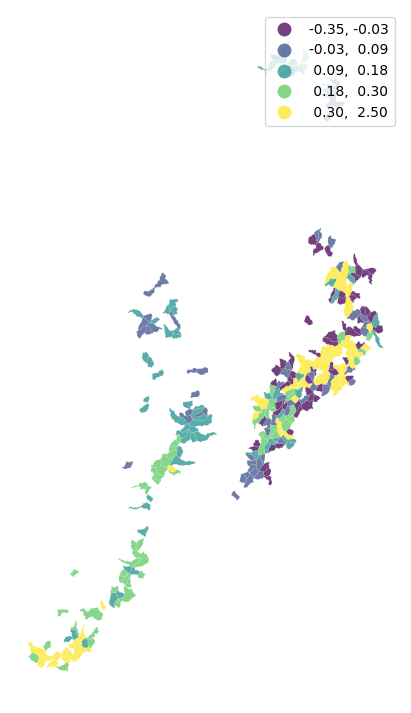

In [13]:
lisa = esda.Moran_Local(pomca_filt['num_species'], w_dist100km)
f, ax = plt.subplots(1, figsize=(9,9))
pomca_filt['Is'] = lisa.Is
pomca_filt.plot(column='Is', cmap='viridis', scheme='quantiles',k=5, edgecolor='white', linewidth=0.1, alpha=0.75, legend=True,ax=ax);
ax.set_axis_off()

In [14]:
# Break observations into significant or not
pomca_filt['significant'] = lisa.p_sim < 0.05
# Store the quadrant they belong to
pomca_filt['quadrant'] = lisa.q

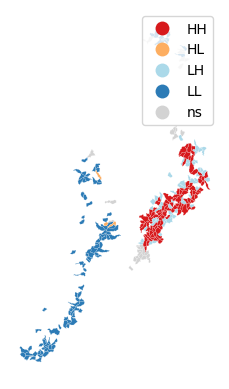

In [15]:
from splot.esda import lisa_cluster
lisa_cluster(lisa, pomca_filt);

c:\Users\danie\miniconda3\envs\GeoSpatial\Lib\site-packages\mapclassify\classifiers.py:1760: UserWarning: Not enough unique values in array to form 5 classes. Setting k to 4.
  self.bins = quantile(y, k=k)


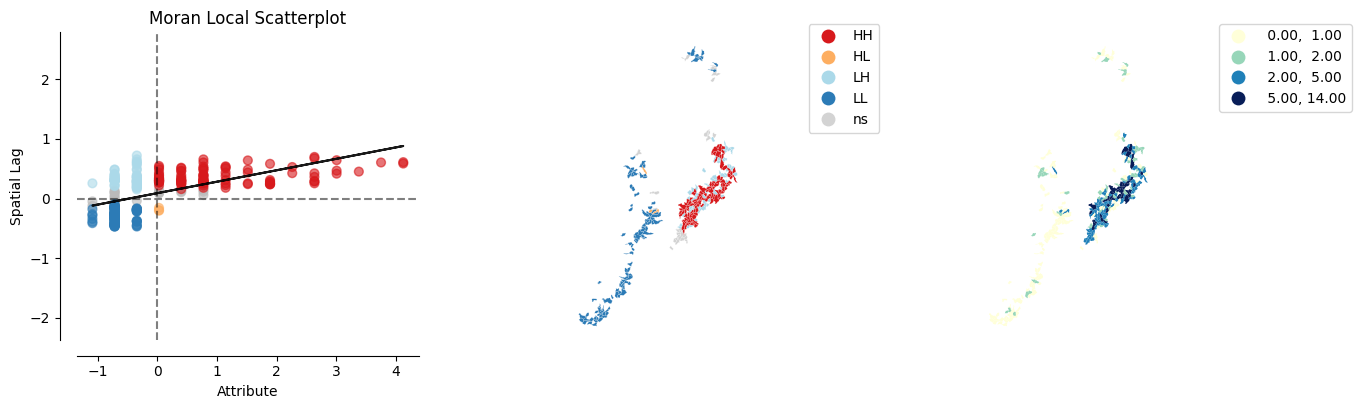

In [16]:
from splot.esda import plot_local_autocorrelation
plot_local_autocorrelation(lisa, pomca_filt, 'num_species');

In [66]:
# Probando K-means
from esda.moran import Moran
import numpy as np
import libpysal.weights.set_operations as Wsets
from libpysal.weights import Queen, KNN
import seaborn as sns
from pysal.lib import weights
import geopandas as gpd
import contextily as cx
from sklearn import cluster
from sklearn.cluster import KMeans, AgglomerativeClustering

In [67]:
kmeans5 = cluster.KMeans(n_clusters=5)
k5cls = kmeans5.fit(pomca_filt[['sp_density']]);

c:\Users\danie\miniconda3\envs\GeoSpatial\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [68]:
k5cls.labels_

array([0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2,
       0, 0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 2, 0,
       0, 0, 2, 1, 1, 1, 2, 2, 0, 1, 2, 4, 2, 2, 4, 2, 2, 1, 2, 0, 1, 0,
       1, 4, 4, 1, 2, 0, 2, 0, 2, 1, 2, 1, 4, 0, 4, 0, 2, 1, 1, 4, 0, 0,
       4, 2, 2, 2, 0, 2, 3, 4, 4, 4, 2, 0, 0, 0, 1, 4, 0, 2, 2, 1, 0, 2,
       2, 1, 4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 2, 0,
       2, 2, 0, 2, 4, 0, 2, 0, 4, 2, 2, 2, 4, 0, 0, 0, 2, 2, 0, 2, 0, 4,
       0, 2, 0, 1, 0, 0, 4, 0, 2, 4, 0, 2, 2, 1, 1, 1, 0, 0, 0, 2, 0, 0,
       0, 0, 0, 0, 2, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 2, 2, 2, 4, 0,
       0, 2, 2, 0, 2, 2, 0, 0, 0, 2, 2, 2, 1, 2, 2, 4, 2, 0, 4, 4, 4, 1,
       2, 2, 2, 4, 4, 4, 4, 2, 0, 2, 0, 0, 1, 2, 4, 2, 2, 0, 0, 2, 0, 2,
       4, 0, 2, 1, 2, 2, 0, 0, 4, 4, 4, 2, 4, 2, 4, 4, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0], dtype=int32)

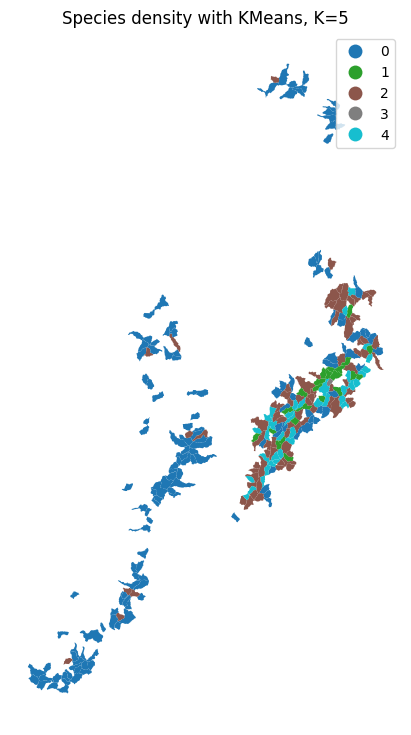

In [69]:
import matplotlib.pyplot as plt

pomca_filt['k5cls'] = k5cls.labels_

# Setup figure and ax
f, ax = plt.subplots(1, figsize=(9, 9))
# Plot unique values choropleth including a legend and with no boundary lines
pomca_filt.plot(column='k5cls', categorical=True, legend=True, linewidth=0, ax=ax)
# Remove axis
ax.set_axis_off()
# Add title
plt.title('Species density with KMeans, K=5')
# Display the map
plt.show()

In [ ]:
# pomca_filt.to_csv('../data/pomca_filt.csv', index=False)